# ANALISIS DE SENTIMIENTO DE TWEETS CON WORD2VEC Y REDES NEURONALES RECURRENTES CON TENSORFLOW
# DATASET : https://www.kaggle.com/datasets/saurabhshahane/twitter-sentiment-dataset

## 1. Instalar librerías

In [1]:
!pip install -q tensorflow gensim scikit-learn nltk kaggle

## 2. Importaciones

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3. Cargar dataset

In [3]:
file_path = "/content/Twitter_Data.csv"
df = pd.read_csv(file_path)

print("Shape inicial:", df.shape)
df.head()

Shape inicial: (162980, 2)


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


# 4 . EDA

In [4]:
df.dtypes

,0
clean_text,object
category,float64


In [5]:
df.isnull().sum()

,0
clean_text,4
category,7


In [6]:
print("Columnas:", df.columns.tolist())
print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nMuestra aleatoria:")
display(df.sample(5))

Columnas: ['clean_text', 'category']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None

Valores nulos:
clean_text    4
category      7
dtype: int64

Muestra aleatoria:


,clean_text,category
74691,just election sympathy for modi,0.0
146978,modi and bjp leadersneck deep corruption have ...,-1.0
22273,nssos statistics show that since modi came pow...,0.0
85001,modi this not fair its called cheating,-1.0
94058,strong supporter modi for the good work had do...,1.0


In [7]:
df.columns = [c.strip() for c in df.columns]

df = df[['clean_text', 'category']].copy()
df = df.dropna()
df['category'] = df['category'].astype(int)

print("Shape después de limpieza:", df.shape)
print(df['category'].value_counts())
df.head()

Shape después de limpieza: (162969, 2)
category
 1    72249
 0    55211
-1    35509
Name: count, dtype: int64


,clean_text,category
0,when modi promised “minimum government maximum...,-1
1,talk all the nonsense and continue all the dra...,0
2,what did just say vote for modi welcome bjp t...,1
3,asking his supporters prefix chowkidar their n...,1
4,answer who among these the most powerful world...,1


## 5. Preprocesamiento de texto

Se realiza:
- minúsculas
- eliminación de URLs
- eliminación de menciones
- eliminación de caracteres no alfabéticos
- tokenización
- remoción de stopwords

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 1]
    return tokens

df['clean_text'] = df['clean_text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize_text)

df.head()

,clean_text,category,tokens
0,when modi promised minimum government maximum ...,-1,"[modi, promised, minimum, government, maximum,..."
1,talk all the nonsense and continue all the dra...,0,"[talk, nonsense, continue, drama, vote, modi]"
2,what did just say vote for modi welcome bjp to...,1,"[say, vote, modi, welcome, bjp, told, rahul, m..."
3,asking his supporters prefix chowkidar their n...,1,"[asking, supporters, prefix, chowkidar, names,..."
4,answer who among these the most powerful world...,1,"[answer, among, powerful, world, leader, today..."


## Eliminar filas vacías tras tokenización

In [9]:
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)
print("Shape final:", df.shape)
df.head()

Shape final: (162893, 3)


,clean_text,category,tokens
0,when modi promised minimum government maximum ...,-1,"[modi, promised, minimum, government, maximum,..."
1,talk all the nonsense and continue all the dra...,0,"[talk, nonsense, continue, drama, vote, modi]"
2,what did just say vote for modi welcome bjp to...,1,"[say, vote, modi, welcome, bjp, told, rahul, m..."
3,asking his supporters prefix chowkidar their n...,1,"[asking, supporters, prefix, chowkidar, names,..."
4,answer who among these the most powerful world...,1,"[answer, among, powerful, world, leader, today..."


# 6. label encoding para categorias

In [10]:
label_map = {-1: 0, 0: 1, 1: 2}
inv_label_map = {0: "negative", 1: "neutral", 2: "positive"}

df['label'] = df['category'].map(label_map)

print(df[['category', 'label']].drop_duplicates().sort_values('category'))
print("\nDistribución de clases:")
print(df['label'].value_counts())

   category  label
0        -1      0
1         0      1
2         1      2

Distribución de clases:
label
2    72244
1    55141
0    35508
Name: count, dtype: int64


# 7.Dividir en train, validation y test

In [11]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['tokens'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 130314
Validation: 16289
Test: 16290


# 8.Entrenar Word2Vec con los textos de entrenamiento

In [12]:
EMBEDDING_DIM = 100
WINDOW = 5
MIN_COUNT = 2

w2v_model = Word2Vec(
    sentences=train_texts,
    vector_size=EMBEDDING_DIM,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=4,
    sg=1
)

print("Tamaño del vocabulario Word2Vec:", len(w2v_model.wv))

Tamaño del vocabulario Word2Vec: 34504


 # 9.Construir vocabulario para la red

In [13]:
word_freq = Counter()
for tokens in train_texts:
    word_freq.update(tokens)

word2idx = {"<PAD>": 0, "<UNK>": 1}

for word, freq in word_freq.items():
    if freq >= MIN_COUNT:
        word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print("Tamaño vocabulario:", len(word2idx))

Tamaño vocabulario: 34506


## 10. Crear matriz de embeddings desde Word2Vec

In [14]:
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(len(word2idx), EMBEDDING_DIM)
).astype(np.float32)

embedding_matrix[word2idx["<PAD>"]] = np.zeros((EMBEDDING_DIM,), dtype=np.float32)

found = 0
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1

print(f"Palabras encontradas en Word2Vec: {found}/{len(word2idx)}")

Palabras encontradas en Word2Vec: 34504/34506


## 11. Convertir tokens a secuencias numéricas

In [15]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(tok, word2idx["<UNK>"]) for tok in tokens]

train_sequences = [encode_tokens(tokens, word2idx) for tokens in train_texts]
val_sequences = [encode_tokens(tokens, word2idx) for tokens in val_texts]
test_sequences = [encode_tokens(tokens, word2idx) for tokens in test_texts]

print("Ejemplo de secuencia:", train_sequences[0][:20])

Ejemplo de secuencia: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 8, 17, 18, 19, 20]


## 12. Padding de secuencias

Todas las secuencias deben tener la misma longitud para entrenar el modelo.

In [16]:
MAX_LEN = 50

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(val_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (130314, 50)
Shape X_val: (16289, 50)
Shape X_test: (16290, 50)


# 13. creamos red neuronal recurrente LSTM en TensorFlow

Se usa:
- `Embedding` inicializada con la matriz de Word2Vec
- `mask_zero=True` para ignorar padding
- `LSTM`
- `Dropout`
- capa final `Dense` con `softmax`

In [17]:
VOCAB_SIZE = len(word2idx)
LSTM_UNITS = 128
DROPOUT_RATE = 0.3

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=True,
        trainable=True
    ),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT_RATE),
    Dense(64, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,450,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,450,600 (13.16 MB)

 Trainable params: 3,450,600 (13.16 MB)

 Non-trainable params: 0 (0.00 B)

## 14. creamos Callbacks

Usaremos:
- `EarlyStopping` para detener si no mejora validation loss
- `ModelCheckpoint` para guardar el mejor modelo

In [18]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_lstm_tf.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

## 15. Entrenamiento de la red neuronal

In [19]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/10
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.7424 - loss: 0.6214 - val_accuracy: 0.9149 - val_loss: 0.2817
Epoch 2/10
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9276 - loss: 0.2468 - val_accuracy: 0.9121 - val_loss: 0.2880
Epoch 3/10
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9430 - loss: 0.1948 - val_accuracy: 0.9133 - val_loss: 0.2913
Epoch 4/10
2037/2037 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9548 - loss: 0.1498 - val_accuracy: 0.9104 - val_loss: 0.3364


# 16 . Evaluación de la red neuronal

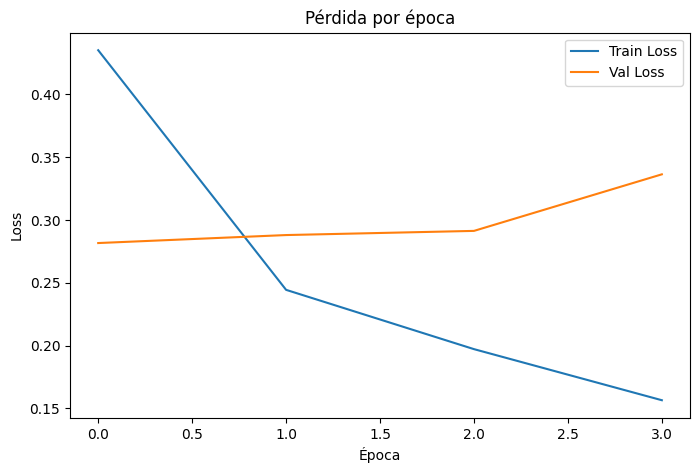

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

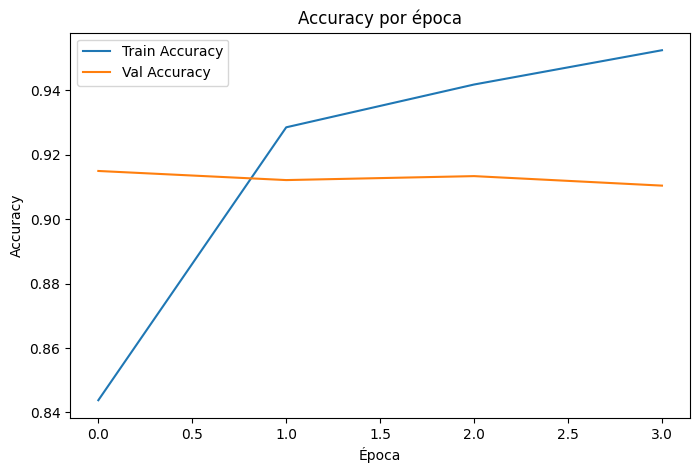

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Evaluación final en test

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss:", round(float(test_loss), 4))
print("Test Accuracy:", round(float(test_acc), 4))

Test Loss: 0.2648
Test Accuracy: 0.9201


### reporte de clasificación

In [24]:
y_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_probs, axis=1)

target_names = ["negative", "neutral", "positive"]
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      3551
     neutral       0.92      0.97      0.94      5514
    positive       0.93      0.92      0.93      7225

    accuracy                           0.92     16290
   macro avg       0.92      0.91      0.91     16290
weighted avg       0.92      0.92      0.92     16290



### matriz de confusión

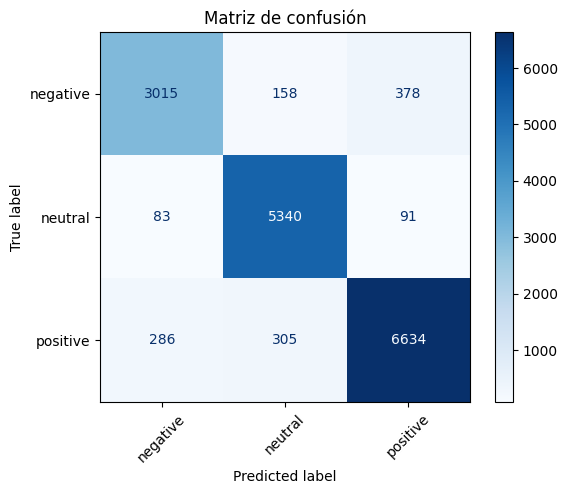

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de confusión")
plt.show()

## 17. probamos la red neuronal

### Funciones para inferencia

In [26]:
def preprocess_for_inference(text):
    text = clean_text(text)
    tokens = tokenize_text(text)
    seq = encode_tokens(tokens, word2idx)
    if len(seq) == 0:
        seq = [word2idx["<UNK>"]]
    seq = pad_sequences([seq], maxlen=MAX_LEN, padding='post', truncating='post')
    return seq

def predict_sentiment(text, model, word2idx):
    seq = preprocess_for_inference(text)
    probs = model.predict(seq, verbose=0)[0]
    pred = int(np.argmax(probs))
    return inv_label_map[pred], probs

### Probar con textos nuevos

In [27]:
examples = [
    "I love this phone, it is amazing and fast",
    "This is the worst service ever",
    "The product is okay, nothing special",
    "I am very happy with the new update",
    "This app is terrible and keeps crashing"
]

for text in examples:
    pred, probs = predict_sentiment(text, model, word2idx)
    print(f"{text} -> {pred} | probs={np.round(probs, 4)}")

I love this phone, it is amazing and fast -> positive | probs=[8.000e-04 0.000e+00 9.991e-01]
This is the worst service ever -> negative | probs=[9.917e-01 5.000e-04 7.800e-03]
The product is okay, nothing special -> positive | probs=[1.600e-03 1.000e-04 9.984e-01]
I am very happy with the new update -> positive | probs=[3.400e-03 1.000e-04 9.965e-01]
This app is terrible and keeps crashing -> negative | probs=[9.943e-01 4.000e-04 5.300e-03]
